# Apo reconstruction with direct methods in quantem 

Notebook from Stephanie Ribet and Georgios Varnavides

Data from B Küçükoğlu et al, Low-dose cryo-electron ptychography of proteins at sub-nanometer resolution, Nature Communications (2025).

In [1]:
import numpy as np
import quantem as em
import matplotlib.pyplot as plt

from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter

print(em.__version__)

/Users/gvarnavides/Documents/papers/mrs-bulletin-phase-retrieval-abcs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.1.8


## Load Calibrated Data

In [2]:
# Data can be downloaded from
dc = em.io.load("data/apo_arina_calibrated.zip")
dc

Dataset(shape=(128, 128, 128, 128), dtype=float32, name='4D-STEM dataset')
  sampling: [20.         20.          0.10225094  0.10225094]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'

In [3]:
PROBE_SEMIANGLE = 4
ENERGY = 300e3

## Direct Ptychography Preprocessing

In [4]:
direct_ptycho = em.diffractive_imaging.direct_ptychography.DirectPtychography.from_dataset4d(
    dc,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    aberration_coefs={}, 
    device="cpu",
    rotation_angle=np.deg2rad(0), 
    max_batch_size=128
)

## Direct Ptychography Optimization

In [26]:
direct_ptycho = direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(0,20000),
        "C12":OptimizationParameter(0, 500),
        "phi12":OptimizationParameter(-np.pi/2, np.pi/2)
    },
    rotation_angle=OptimizationParameter(np.deg2rad(-100),np.deg2rad(-80)),
    deconvolution_kernel='parallax',
)

Best trial: 23. Best value: 4.49659e-09: 100%|██████████████████████████████████████████████████| 50/50 [00:37<00:00,  1.34it/s]


Optimized state:

 HyperparameterState(
  initial_rotation_angle=np.float64(0.0),
  optimized_aberrations={'C10': 15629.309619792379, 'C12': 87.99657789489045, 'phi12': -0.8583457281195899},
  optimized_rotation_angle=-1.5345162622424053,
)


# final plotting

In [27]:
parallax_obj_no_upsample = direct_ptycho.reconstruct(
    deconvolution_kernel='parallax',
    max_batch_size=128,
    verbose=False,
).obj

par_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='parallax',
    max_batch_size=128,
    upsampling_factor=2,
    verbose=False,
).obj

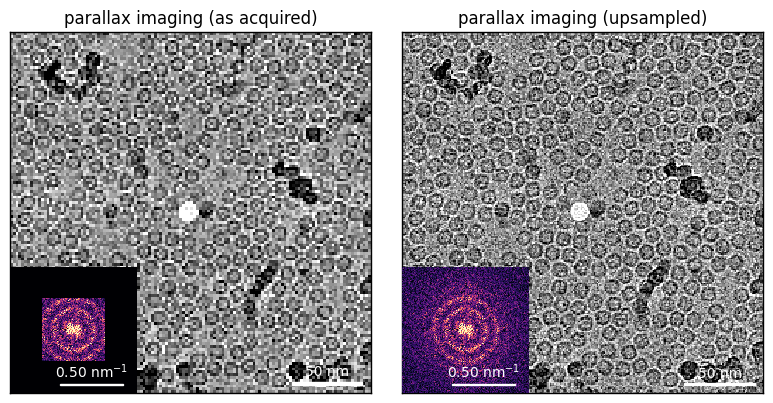

In [31]:
def fft(ar): 
    n0 = ar.shape
    w0 = np.hanning(n0[1]) * np.hanning(n0[0])[:, None]
    ar_fft = np.abs(np.fft.fftshift(np.fft.fft2(w0 * ar.copy())))
    return ar_fft
    
norm = em.visualization.NormalizationConfig(
    # interval_type="manual",
    upper_quantile=0.995,
    lower_quantile = 0
)

crop = 20
pad = np.abs(par_obj.shape[0] - parallax_obj_no_upsample.shape[0] )//2

scalebar_real = em.visualization.ScalebarConfig(
    sampling=dc.sampling[0]/10,
    units='nm',
    length=50,
)

scalebar_real_up = em.visualization.ScalebarConfig(
    sampling=dc.sampling[0]/10/2,
    units='nm',
    length=50,
)

scalebar_reciprocal = em.visualization.ScalebarConfig(
    sampling=np.fft.fftfreq(par_obj.shape[0],dc.sampling[0]/2/10)[1],
    units=r'$\mathrm{nm}^{-1}$',
    length=0.5,
)

fig, ax = em.visualization.show_2d(
    [
        parallax_obj_no_upsample,
        par_obj,
    ],
    title=["parallax imaging (as acquired)", "parallax imaging (upsampled)"],
    axsize=(4,4),
    returnfig = True,
    scalebar=[scalebar_real,scalebar_real_up]
);


ax_inset = ax[0].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    np.pad(fft(parallax_obj_no_upsample),((pad, pad),(pad, pad))),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);



ax_inset = ax[1].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(par_obj),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

plt.savefig('apo_upsample.pdf', bbox_inches = "tight")